In [2]:
import os
import json
import requests
from dotenv import load_dotenv
from typing import List, Dict, Any

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from newsapi import NewsApiClient

In [3]:
load_dotenv()

True

In [4]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
FREECRYPTO_TOKEN = os.getenv("FREECRYPTO_TOKEN")
NEWSAPI_KEY = os.getenv("NEWSAPI_KEY")

In [5]:
llm = ChatOpenAI(model="gpt-4")

In [6]:
@tool
def crypto_list_tool(limit: int = 25) -> str:
    """
    Fetches a list of available cryptocurrencies (symbol + name) from FreeCryptoAPI.
    Args:
        limit (int): Max number of coins to return (to keep responses compact).
    Returns:
        str: JSON string with a condensed list: [{"symbol": "...", "name": "..."}, ...]
    """
    url = "https://api.freecryptoapi.com/v1/getCryptoList"
    headers = {"Authorization": f"Bearer {FREECRYPTO_TOKEN}"}
    resp = requests.get(url, headers=headers, timeout=30)
    try:
        data = resp.json()
    except Exception:
        return json.dumps({"status": False, "error": "Invalid JSON from API"})

    
    if isinstance(data, list):
        slim = []
        for item in data[: max(1, limit)]:
            sym = item.get("symbol") or item.get("Symbol") or item.get("ticker")
            nm = item.get("name") or item.get("Name")
            if sym or nm:
                slim.append({"symbol": sym, "name": nm})
        return json.dumps({"status": True, "coins": slim}, indent=2)

    
    return json.dumps(data, indent=2)

In [7]:
@tool
def crypto_data_tool(symbol: str) -> str:
    """
    Fetches detailed data for a given crypto symbol (e.g., BTC) from FreeCryptoAPI.
    Args:
       - symbol (str): Ticker symbol like 'BTC', 'ETH', etc.
    Returns:
        str: JSON string of the API response.
    """
    url = "https://api.freecryptoapi.com/v1/getData"
    headers = {"Authorization": f"Bearer {FREECRYPTO_TOKEN}"}
    params = {"symbol": symbol.upper().strip()}
    resp = requests.get(url, headers=headers, params=params, timeout=30)
    try:
        data = resp.json()
    except Exception:
        return json.dumps({"status": False, "error": "Invalid JSON from API"})

    return json.dumps(data, indent=2)

In [8]:
@tool
def crypto_news_tool(query: str = "crypto", mode: str = "top", max_items: int = 5) -> str:
    """
    Fetches recent/important news using NewsAPI and returns a condensed list. 
    Args:
        - query (str): Search query, e.g. 'bitcoin', 'ethereum', 'crypto regulation'
        - max_items (int): Max number of articles to return. (default: 5)
    Returns:
        str: JSON string with fields: title, source, url, publishedAt
    """
    newsapi = NewsApiClient(api_key=NEWSAPI_KEY)

    try:
        res = newsapi.get_everything(
            q = query,
            language = "en",
            sort_by = "publishedAt",
            page = 1            
        )
        articles = res.get("articles", [])
        
    except Exception as e:
        return json.dumps({"status": False, "error": str(e)})


    slim: List[Dict[str, Any]] = []
    for a in articles[: max(1, max_items)]:
        slim.append(
            {
                "title": a.get("title"),
                "source": (a.get("source") or {}).get("name"),
                "url": a.get("url"),
                "publishedAt": a.get("publishedAt"),
                "description":  a.get("description"),
                "content": a.get("content"),
            }
        )

    return json.dumps(
        {
            "status": True,
            "totalResults": len(articles),
            "returned": len(slim),
            "articles": slim,
        },
        indent=2,
    )


In [9]:
tools = [crypto_list_tool, crypto_data_tool, crypto_news_tool]
tool_node = ToolNode(tools=tools)
llm_with_tools = llm.bind_tools(tools)

In [10]:
sys_msg = SystemMessage(
    content="""
You are a professional Crypto Market Analyst Agent.
You answer user questions about cryptocurrencies, market data, and recent news.

AVAILABLE TOOLS:
- crypto_list_tool(limit): get a condensed list of available crypto tickers.
- crypto_data_tool(symbol): get data for a symbol (e.g., BTC, ETH).
- crypto_news_tool(query, max_items): get condensed news (headlines + URLs + snippets).

GUIDELINES:
1) Think step-by-step about the user's question and decide which tools to call.
2) Use tools to retrieve data; do not fabricate metrics or prices.
3) Cite evidence explicitly by referencing the fields you retrieved (e.g., “priceUsd”).
4) Keep responses concise and scannable with bullet points where appropriate.
5) Provide helpful context/definitions when the user seems new to crypto.

DO'S AND DON'TS:
- If an endpoint returns errors or lacks access, explain clearly and propose alternatives.
- Don’t reveal API keys or tokens.

FORMAT:
- Use sections when helpful: “Summary”, “Data”, “What it means”, “Next steps”.
"""
)


In [11]:
def assistant(state: MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [ ]:
builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", tool_node)

builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

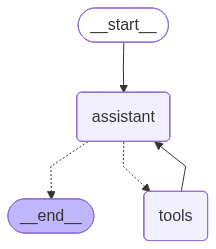

In [13]:
from IPython.display import Image, display
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "crypto-thread-1"}}

messages = [HumanMessage(content="Look at the most reacent news for both xrp and doge as well as the prices tell me is it worth investing and in which one ")]
out = react_graph_memory.invoke({"messages": messages}, config)
for m in out["messages"]:
    try:
        m.pretty_print()
    except Exception:
        print(m)


================================ Human Message =================================

Look at the most reacent news for both xrp and doge as well as the prices tell me is it worth investing and in which one 
================================== Ai Message ==================================
Tool Calls:
  crypto_data_tool (call_oKbjuMIQV0nuUEhklPzGTuvB)
 Call ID: call_oKbjuMIQV0nuUEhklPzGTuvB
  Args:
    symbol: XRP
================================= Tool Message =================================
Name: crypto_data_tool

{
  "status": "success",
  "symbols": [
    {
      "symbol": "XRP",
      "last": "2.3269",
      "last_btc": "0.000022574348907716",
      "lowest": "2.3117",
      "highest": "2.4027",
      "date": "2025-11-06 10:52:53",
      "daily_change_percentage": "-1.2854233836755",
      "source_exchange": "binance"
    }
  ]
}
================================== Ai Message ==================================
Tool Calls:
  crypto_data_tool (call_e26vyTRDBayFEcD5CnGqgnuP)
 Call ID: call

In [ ]:
print("✨ Crypto ReAct Agent — type 'exit' to quit. ✨ \n")

config = {"configurable": {"thread_id": "crypto-thread-1"}}


while True:
    try:
        user_input = input("👤 You: ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\n👋 Bye!")
        break

    if not user_input:
        continue
    if user_input.lower() in {"exit", "quit"}:
        print("👋 Bye!")
        break

    try:
        messages = [HumanMessage(content=user_input)]
        result = react_graph_memory.invoke({"messages": messages}, config)

        last_ai = next((m for m in reversed(result["messages"]) if m.type == "ai"), None)
        if last_ai:
            print(f"🤖 Agent: {last_ai.content}\n")
        else:
            print("🤖 Agent: [No reply]\n")
        
        
    except Exception as e:
        print(f"⚠️ Error: {e}")
